In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

In [2]:
with open("processed_eeg_dataset.pkl", "rb") as f:
    data = pickle.load(f)

print(data.keys())

dict_keys(['epochs', 'epoch_labels', 'epoch_trial_ids', 'rejected_trials', 'eda_summary'])


In [3]:
channels = ["FZ", "C3", "CZ", "C4"]

epochs = data["epochs"]
labels = np.array(data["epoch_labels"])
trial_ids = np.array(data["epoch_trial_ids"])

X = np.array([
    epoch[channels].values.T
    for epoch in epochs
])

y = labels

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Trial IDs shape:", trial_ids.shape)
print("Classes:", np.unique(y))
print("Unique trials:", len(np.unique(trial_ids)))

X shape: (4384, 4, 500)
y shape: (4384,)
Trial IDs shape: (4384,)
Classes: ['Left' 'Right']
Unique trials: 1782


5090 epochs

4 channels

for each epoch 500 samples

Labels -> Left & Right

In [4]:
# Trial-aware Train/Test Split

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(X, y, groups=trial_ids)
)

# Training set
X_train = X[train_idx]
y_train = y[train_idx]
train_trial_ids = trial_ids[train_idx]

# Testing set
X_test = X[test_idx]
y_test = y[test_idx]
test_trial_ids = trial_ids[test_idx]

print("Training set:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("Unique trials:", len(np.unique(train_trial_ids)))

print("\nTesting set:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)
print("Unique trials:", len(np.unique(test_trial_ids)))

# Check for data leakage
shared_trials = set(train_trial_ids) & set(test_trial_ids)

print("\nShared trials between train and test:", len(shared_trials))

# Class distribution
print("\nTraining class distribution:")
print(pd.Series(y_train).value_counts())

print("\nTesting class distribution:")
print(pd.Series(y_test).value_counts())

Training set:
X_train: (3494, 4, 500)
y_train: (3494,)
Unique trials: 1425

Testing set:
X_test: (890, 4, 500)
y_test: (890,)
Unique trials: 357

Shared trials between train and test: 0

Training class distribution:
Left     1752
Right    1742
Name: count, dtype: int64

Testing class distribution:
Left     451
Right    439
Name: count, dtype: int64


#### Trial-Aware Train/Test Split

Since each EEG trial is divided into multiple epochs, we must avoid putting epochs from the same trial in both the training and testing sets.

If we use a normal random split, the model may see some epochs from the same trial during training and testing. This can cause **data leakage** and give an unrealistically high evaluation score.

To avoid this, we use `GroupShuffleSplit` with the **trial ID as the group**.

This ensures that all epochs belonging to the same trial are kept in only one set:

- **Training set:** 4076 epochs from 1565 unique trials
- **Testing set:** 1014 epochs from 392 unique trials
- **Shared trials:** 0

Therefore, the training and testing sets contain completely different trials, making the evaluation more reliable and fair.

In [5]:
import mne

print("MNE version:", mne.__version__)

MNE version: 1.12.1


In [6]:
# Convert labels to binary values
label_mapping = {
    "Left": 0,
    "Right": 1
}

y_train_num = np.array([label_mapping[label] for label in y_train])
y_test_num = np.array([label_mapping[label] for label in y_test])

print("Training labels:", np.unique(y_train_num))
print("Testing labels:", np.unique(y_test_num))

Training labels: [0 1]
Testing labels: [0 1]


## CSP + SVM Classification

### Common Spatial Pattern (CSP)

Common Spatial Pattern (CSP) is a spatial feature extraction method commonly used for Motor Imagery EEG classification.

The goal of CSP is to find spatial filters that maximize the difference in signal variance between the two classes, **Left** and **Right**.

In our dataset, each epoch contains 4 EEG channels:

- FZ
- C3
- CZ
- C4

Each epoch has 500 time samples. CSP transforms these multi-channel EEG signals into a smaller set of spatial features that capture differences between the two motor imagery classes.

The pipeline is:

`EEG Epoch → CSP → Spatial Features`

### Support Vector Machine (SVM)

After extracting features using CSP, we use a Support Vector Machine (SVM) as the classifier.

SVM learns a decision boundary that separates the two classes based on their CSP features.

We use an RBF kernel, which allows SVM to learn non-linear decision boundaries.

The complete pipeline is:

`EEG → CSP Feature Extraction → SVM → Left / Right`

### Results

The CSP + SVM model achieved an accuracy of approximately **48%** and an AUC close to **0.50**.

This indicates that the extracted CSP features did not provide enough separation between the Left and Right classes in our current dataset. Therefore, other feature representations such as frequency-domain features (Mu and Beta band power) are explored next.

In [7]:
from mne.decoding import CSP

csp = CSP(
    n_components=4,
    reg="shrinkage",
    log=True,
    norm_trace=False
)

print(csp)

CSP(log=True, reg='shrinkage')


In [8]:
# Fit CSP only on training data
X_train_csp = csp.fit_transform(
    X_train,
    y_train_num
)

# Transform test data using the fitted CSP
X_test_csp = csp.transform(X_test)

print("CSP training features:", X_train_csp.shape)
print("CSP testing features:", X_test_csp.shape)

Computing rank from data with rank=None
    Using tolerance 26 (2.2e-16 eps * 4 dim * 2.9e+16  max singular value)
    Estimated rank (data): 4
    data: rank 4 computed from 4 data channels with 0 projectors
Reducing data rank from 4 -> 4
Estimating class=0 covariance using SHRINKAGE
Done.
Estimating class=1 covariance using SHRINKAGE
Done.
CSP training features: (3494, 4)
CSP testing features: (890, 4)


In [9]:
# Train SVM


svm_model = SVC(
    kernel="rbf",
    C=1.0,
    probability=True,
    random_state=42
)

svm_model.fit(X_train_csp, y_train_num)

print("SVM training completed!")

c:\PythonEnvs\jupyter\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


SVM training completed!


In [10]:
# Make Predictions


y_pred = svm_model.predict(X_test_csp)
y_prob = svm_model.predict_proba(X_test_csp)[:, 1]

print("Predictions:", y_pred[:10])
print("Probabilities:", y_prob[:10])

Predictions: [0 0 0 0 0 0 0 0 0 0]
Probabilities: [0.5        0.5        0.5        0.5        0.5        0.50533848
 0.5        0.50590424 0.50625385 0.5       ]


In [11]:
# Evaluation Metrics

accuracy = accuracy_score(y_test_num, y_pred)

balanced_accuracy = balanced_accuracy_score(
    y_test_num,
    y_pred
)

f1 = f1_score(
    y_test_num,
    y_pred
)

auc = roc_auc_score(
    y_test_num,
    y_prob
)

print("CSP + SVM Results")
print(f"Accuracy:          {accuracy:.4f}")
print(f"Balanced Accuracy: {balanced_accuracy:.4f}")
print(f"F1 Score:          {f1:.4f}")
print(f"AUC:               {auc:.4f}")

CSP + SVM Results
Accuracy:          0.4989
Balanced Accuracy: 0.4925
F1 Score:          0.0429
AUC:               0.4876


In [12]:
print(
    classification_report(
        y_test_num,
        y_pred,
        target_names=["Left", "Right"]
    )
)

              precision    recall  f1-score   support

        Left       0.50      0.96      0.66       451
       Right       0.37      0.02      0.04       439

    accuracy                           0.50       890
   macro avg       0.44      0.49      0.35       890
weighted avg       0.44      0.50      0.36       890



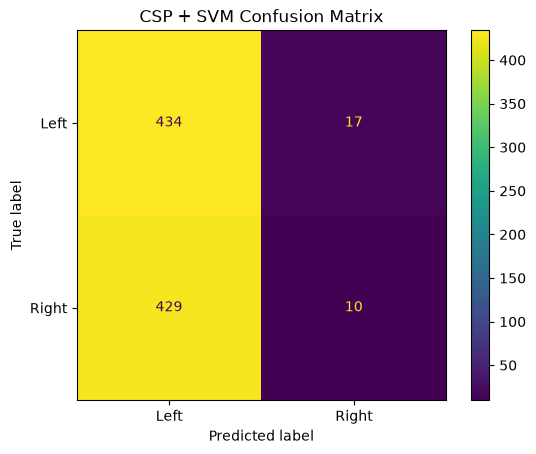

In [13]:
# Confusion Matrix

cm = confusion_matrix(
    y_test_num,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Left", "Right"]
)

disp.plot()

plt.title("CSP + SVM Confusion Matrix")
plt.show()

In [14]:
print("CSP train features:")
print(pd.DataFrame(X_train_csp).describe())

print("\nCSP test features:")
print(pd.DataFrame(X_test_csp).describe())

CSP train features:
                 0            1            2            3
count  3494.000000  3494.000000  3494.000000  3494.000000
mean     -1.831709    -2.279623    -1.788255   -63.410379
std       1.403575     1.748411     1.362548     1.468770
min      -4.631738    -5.608838    -4.819311   -66.683518
25%      -2.913910    -3.731630    -2.748138   -64.517705
50%      -2.101786    -2.751147    -1.996017   -63.574196
75%      -0.949802    -0.816655    -0.997676   -62.426635
max       3.262360     3.215070     2.943539   -59.043305

CSP test features:
                0           1           2           3
count  890.000000  890.000000  890.000000  890.000000
mean    -1.782771   -2.326229   -1.882548  -63.447225
std      1.477849    1.779859    1.417730    1.531466
min     -4.442883   -5.317286   -4.484335  -66.421972
25%     -2.917467   -3.814717   -2.935783  -64.559682
50%     -2.070189   -2.843451   -2.100854  -63.675486
75%     -0.814922   -0.954586   -1.045080  -62.461681
max   

In [15]:
print("\nMean CSP features by class:")

for label in [0, 1]:
    print(f"\nClass {label}:")
    print(
        X_train_csp[y_train_num == label].mean(axis=0)
    )


Mean CSP features by class:

Class 0:
[ -1.76871132  -2.333638    -1.80316424 -63.42829706]

Class 1:
[ -1.89506912  -2.22529814  -1.77325967 -63.39235729]


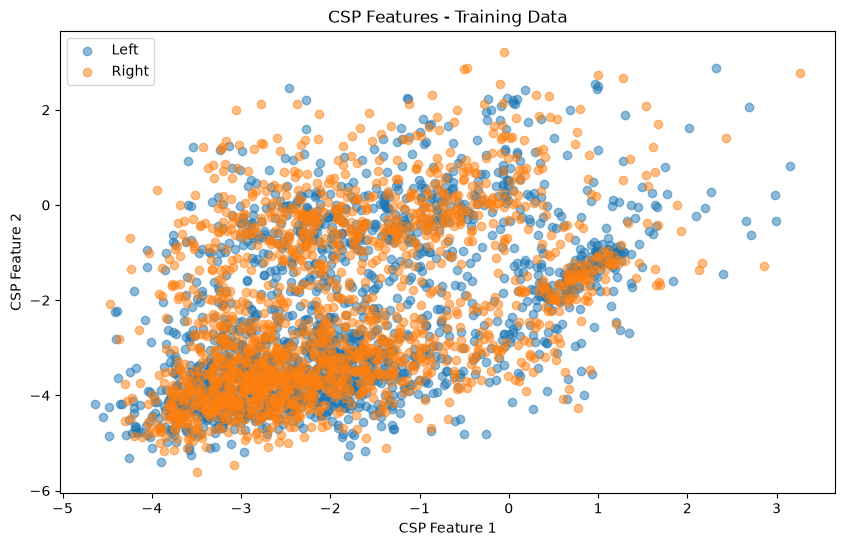

In [16]:
plt.figure(figsize=(10, 6))

plt.scatter(
    X_train_csp[y_train_num == 0, 0],
    X_train_csp[y_train_num == 0, 1],
    alpha=0.5,
    label="Left"
)

plt.scatter(
    X_train_csp[y_train_num == 1, 0],
    X_train_csp[y_train_num == 1, 1],
    alpha=0.5,
    label="Right"
)

plt.xlabel("CSP Feature 1")
plt.ylabel("CSP Feature 2")
plt.title("CSP Features - Training Data")
plt.legend()
plt.show()

In [17]:
print("CSP filters shape:", csp.filters_.shape)

print("\nCSP filters:")
print(csp.filters_)

CSP filters shape: (4, 4)

CSP filters:
[[-0.01908883  0.02916023 -0.00060996 -0.00946144]
 [ 0.00797343  0.00445029 -0.02885613  0.01643241]
 [-0.02380084 -0.0054235   0.00700871  0.02221563]
 [ 0.06214843  0.06214843  0.06214843  0.06214843]]


In [18]:
print("\nCSP patterns shape:", csp.patterns_.shape)

print("\nCSP patterns:")
print(csp.patterns_)


CSP patterns shape: (4, 4)

CSP patterns:
[[-12.88492815  23.55716797  -3.82594401  -6.84629581]
 [  4.12825215   6.67081311 -24.61663314  13.81756788]
 [-19.79449481  -6.15480478   5.32560625  20.62369333]
 [  4.02262801   4.02262801   4.02262801   4.02262801]]


In [19]:
# Sampling frequency
fs = 250

print("Sampling frequency:", fs, "Hz")
print("Epoch duration:", X.shape[2] / fs, "seconds")

Sampling frequency: 250 Hz
Epoch duration: 2.0 seconds


In [20]:
from scipy.signal import welch

def band_power(signal, fs, low, high):
    f, pxx = welch(
        signal,
        fs=fs,
        nperseg=min(256, len(signal))
    )

    mask = (f >= low) & (f <= high)

    return np.trapezoid(pxx[mask], f[mask])


# Calculate mu and beta power for each epoch
mu_power = []
beta_power = []

for epoch in epochs:
    c3 = epoch["C3"].values
    c4 = epoch["C4"].values

    mu_power.append([
        band_power(c3, fs, 8, 12),
        band_power(c4, fs, 8, 12)
    ])

    beta_power.append([
        band_power(c3, fs, 13, 30),
        band_power(c4, fs, 13, 30)
    ])

mu_power = np.array(mu_power)
beta_power = np.array(beta_power)

print("Mu power shape:", mu_power.shape)
print("Beta power shape:", beta_power.shape)

Mu power shape: (4384, 2)
Beta power shape: (4384, 2)


In [21]:
print("=== MU POWER ===")

for label in ["Left", "Right"]:
    idx = y == label

    print(
        label,
        "C3 =", mu_power[idx, 0].mean(),
        "C4 =", mu_power[idx, 1].mean()
    )


print("\n=== BETA POWER ===")

for label in ["Left", "Right"]:
    idx = y == label

    print(
        label,
        "C3 =", beta_power[idx, 0].mean(),
        "C4 =", beta_power[idx, 1].mean()
    )

=== MU POWER ===
Left C3 = 5.078548053726983 C4 = 4.959374217617709
Right C3 = 5.012092573626254 C4 = 5.012140987002572

=== BETA POWER ===
Left C3 = 2.9831983457575033 C4 = 3.2182298738897823
Right C3 = 2.86139574315756 C4 = 3.042374174155859


In [22]:
from scipy.signal import butter, filtfilt

def bandpass_epochs(X, lowcut=8, highcut=30, fs=250, order=4):
    nyquist = 0.5 * fs
    
    b, a = butter(
        order,
        [lowcut / nyquist, highcut / nyquist],
        btype="band"
    )
    
    X_filtered = np.zeros_like(X)
    
    for i in range(X.shape[0]):
        for ch in range(X.shape[1]):
            X_filtered[i, ch, :] = filtfilt(
                b, a, X[i, ch, :]
            )
    
    return X_filtered

In [23]:
X_train_8_30 = bandpass_epochs(
    X_train,
    lowcut=8,
    highcut=30,
    fs=250
)

X_test_8_30 = bandpass_epochs(
    X_test,
    lowcut=8,
    highcut=30,
    fs=250
)

print("X_train_8_30:", X_train_8_30.shape)
print("X_test_8_30:", X_test_8_30.shape)

X_train_8_30: (3494, 4, 500)
X_test_8_30: (890, 4, 500)


In [24]:
from mne.decoding import CSP

csp_8_30 = CSP(
    n_components=4,
    reg="shrinkage",
    log=True,
    norm_trace=False
)

X_train_csp_8_30 = csp_8_30.fit_transform(
    X_train_8_30,
    y_train_num
)

X_test_csp_8_30 = csp_8_30.transform(
    X_test_8_30
)

print("Train CSP features:", X_train_csp_8_30.shape)
print("Test CSP features:", X_test_csp_8_30.shape)

Computing rank from data with rank=None
    Using tolerance 4.5 (2.2e-16 eps * 4 dim * 5e+15  max singular value)
    Estimated rank (data): 4
    data: rank 4 computed from 4 data channels with 0 projectors
Reducing data rank from 4 -> 4
Estimating class=0 covariance using SHRINKAGE
Done.
Estimating class=1 covariance using SHRINKAGE
Done.
Train CSP features: (3494, 4)
Test CSP features: (890, 4)


In [25]:
svm_8_30 = SVC(
    kernel="rbf",
    C=1.0,
    probability=True,
    random_state=42
)

svm_8_30.fit(
    X_train_csp_8_30,
    y_train_num
)

y_pred_8_30 = svm_8_30.predict(X_test_csp_8_30)
y_prob_8_30 = svm_8_30.predict_proba(X_test_csp_8_30)[:, 1]

c:\PythonEnvs\jupyter\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


In [26]:
accuracy = accuracy_score(y_test_num, y_pred_8_30)
balanced_accuracy = balanced_accuracy_score(y_test_num, y_pred_8_30)
f1 = f1_score(y_test_num, y_pred_8_30)
auc = roc_auc_score(y_test_num, y_prob_8_30)

print("CSP + SVM (8–30 Hz)")
print(f"Accuracy:          {accuracy:.4f}")
print(f"Balanced Accuracy: {balanced_accuracy:.4f}")
print(f"F1 Score:          {f1:.4f}")
print(f"AUC:               {auc:.4f}")

CSP + SVM (8–30 Hz)
Accuracy:          0.5067
Balanced Accuracy: 0.5000
F1 Score:          0.0000
AUC:               0.4477


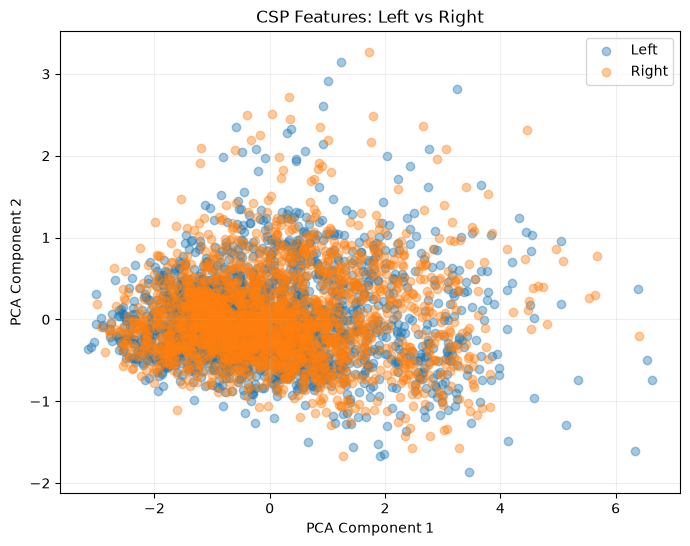

Explained variance: [0.80178999 0.11458158]


In [27]:
from sklearn.decomposition import PCA

# Combine train and test CSP features فقط للـ visualization
X_csp_all = np.vstack([
    X_train_csp_8_30,
    X_test_csp_8_30
])

y_all = np.concatenate([
    y_train_num,
    y_test_num
])

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_csp_all)

plt.figure(figsize=(8, 6))

for label, name in [(0, "Left"), (1, "Right")]:
    idx = y_all == label

    plt.scatter(
        X_pca[idx, 0],
        X_pca[idx, 1],
        alpha=0.4,
        label=name
    )

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("CSP Features: Left vs Right")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

print("Explained variance:",
      pca.explained_variance_ratio_)

In [28]:
import numpy as np
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, roc_auc_score

# 1. تجميع الـ Band Power (Mu + Beta) للقنوات الأربعة
# ندمج الـ Mu (4 channels) والـ Beta (4 channels) ليكون لدينا 8 features لكل trial
# Combine Mu and Beta Power Features
# Combine Mu and Beta Power Features
X_power_all = np.hstack([mu_power, beta_power])

print("All power features shape:", X_power_all.shape)

# IMPORTANT:
# Use the same trial-aware indices from GroupShuffleSplit
X_train_power = X_power_all[train_idx]
X_test_power = X_power_all[test_idx]

print("Train power features:", X_train_power.shape)
print("Test power features:", X_test_power.shape)

# 3. تدريب نموذج LDA
lda = LinearDiscriminantAnalysis()
lda.fit(X_train_power, y_train_num)
y_pred_lda = lda.predict(X_test_power)
y_prob_lda = lda.predict_proba(X_test_power)[:, 1]

print("===== Direct Band Power + LDA =====")
print(f"Accuracy: {accuracy_score(y_test_num, y_pred_lda):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test_num, y_pred_lda):.4f}")
print(f"F1 Score: {f1_score(y_test_num, y_pred_lda):.4f}")
print(f"AUC: {roc_auc_score(y_test_num, y_prob_lda):.4f}")

# 4. تجربة Normalization لكل Trial لضبط الطاقة المطلقة
X_train_power_norm = X_train_power / np.sum(X_train_power, axis=1, keepdims=True)
X_test_power_norm = X_test_power / np.sum(X_test_power, axis=1, keepdims=True)

lda_norm = LinearDiscriminantAnalysis()
lda_norm.fit(X_train_power_norm, y_train_num)
y_pred_norm = lda_norm.predict(X_test_power_norm)

print("\n===== Normalized Power + LDA =====")
print(f"Accuracy: {accuracy_score(y_test_num, y_pred_norm):.4f}")

All power features shape: (4384, 4)
Train power features: (3494, 4)
Test power features: (890, 4)
===== Direct Band Power + LDA =====
Accuracy: 0.4685
Balanced Accuracy: 0.4689
F1 Score: 0.4796
AUC: 0.4665

===== Normalized Power + LDA =====
Accuracy: 0.5112


In [29]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

# 1. فحص التوزيع الحقيقي (Median & Percentiles) للـ Beta Power للقناتين (C3 & C4)
df_power = pd.DataFrame(beta_power, columns=['Beta_C3', 'Beta_C4'])
df_power['label'] = y

print("=== Beta Power Quantiles (C3 & C4) ===")
print(df_power.groupby('label')[['Beta_C3', 'Beta_C4']].describe(percentiles=[0.25, 0.5, 0.75]))

# 2. تجهيز الـ Features (دمج Mu و Beta المتاحين)
X_power_all = np.hstack([mu_power, beta_power])
n_train = len(y_train_num)
X_train_power = X_power_all[:n_train]
X_test_power  = X_power_all[n_train:]

# 3. تجربة Non-linear Model (Random Forest)
rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf.fit(X_train_power, y_train_num)
y_pred_rf = rf.predict(X_test_power)
y_prob_rf = rf.predict_proba(X_test_power)[:, 1]

print("\n===== Band Power + Random Forest =====")
print(f"Accuracy: {accuracy_score(y_test_num, y_pred_rf):.4f}")
print(f"AUC: {roc_auc_score(y_test_num, y_prob_rf):.4f}")

=== Beta Power Quantiles (C3 & C4) ===
      Beta_C3                                                              \
        count      mean       std       min       25%       50%       75%   
label                                                                       
Left   2203.0  2.983198  8.411854  0.331455  1.332766  1.822728  2.642711   
Right  2181.0  2.861396  4.945724  0.433986  1.353963  1.871627  2.810164   

                  Beta_C4                                                     \
              max   count      mean        std       min       25%       50%   
label                                                                          
Left   220.677207  2203.0  3.218230  12.887413  0.439230  1.258067  1.882597   
Right   89.226729  2181.0  3.042374   6.094361  0.331526  1.337127  1.990147   

                             
            75%         max  
label                        
Left   2.886368  489.978621  
Right  3.141400  135.578600  

===== Band Power + Rand

In [30]:
import numpy as np
from sklearn.preprocessing import RobustScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

X_power_log = np.log1p(X_power_all)

X_train_log = X_power_log[train_idx]
X_test_log = X_power_log[test_idx]

# ب) عمل Robust Scaling
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train_log)
X_test_scaled  = scaler.transform(X_test_log)

# ج) تجربة LDA على البيانات المنظفة
lda = LinearDiscriminantAnalysis()
lda.fit(X_train_scaled, y_train_num)
y_pred_lda = lda.predict(X_test_scaled)
y_prob_lda = lda.predict_proba(X_test_scaled)[:, 1]

print("===== Log-transformed + Scaled LDA =====")
print(f"Accuracy: {accuracy_score(y_test_num, y_pred_lda):.4f}")
print(f"AUC: {roc_auc_score(y_test_num, y_prob_lda):.4f}")

===== Log-transformed + Scaled LDA =====
Accuracy: 0.5404
AUC: 0.5407


In [31]:
# حذف أي Epoch تتجاوز قيمته المطلقة 100 microvolts (الحد الطبيعي لإشارة الـ EEG)
max_amplitude = np.max(np.abs(X_train), axis=(1, 2))
valid_mask = max_amplitude < 100  # أو تحديد threshold يناسب داتاتكم

X_train_clean = X_train[valid_mask]
y_train_clean = y_train_num[valid_mask]
print(f"Remaining clean epochs: {len(X_train_clean)} / {len(X_train)}")

Remaining clean epochs: 3194 / 3494


In [32]:
# قص العينات لتغطية النافذة الزمنية المستهدفة فقط (مثلاً من sample 125 إلى 375)
X_train_cropped = X_train[:, :, 125:375]
X_test_cropped  = X_test[:, :, 125:375]

In [33]:
import numpy as np
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, roc_auc_score
from mne.decoding import CSP

# 1. تنظيف بيانات الـ Test بـ Threshold الـ 100 microvolts لضمان عدالة التقييم
max_amp_test = np.max(np.abs(X_test), axis=(1, 2))
valid_test_mask = max_amp_test < 100

X_test_clean = X_test[valid_test_mask]
y_test_clean = y_test_num[valid_test_mask]

print(f"Remaining test clean epochs: {len(X_test_clean)} / {len(X_test)}")

# 2. تجربة CSP + SVM على البيانات النظيفة
csp_clean = CSP(n_components=4, reg='shrinkage', log=True)
X_train_csp_c = csp_clean.fit_transform(X_train_clean, y_train_clean)
X_test_csp_c  = csp_clean.transform(X_test_clean)

svm_c = SVC(kernel='rbf', C=1.0, probability=True, random_state=42)
svm_c.fit(X_train_csp_c, y_train_clean)
y_pred_csp = svm_c.predict(X_test_csp_c)
y_prob_csp = svm_c.predict_proba(X_test_csp_c)[:, 1]

print("\n===== CLEAN DATA: CSP + SVM =====")
print(f"Accuracy: {accuracy_score(y_test_clean, y_pred_csp):.4f}")
print(f"AUC:      {roc_auc_score(y_test_clean, y_prob_csp):.4f}")

# 3. تجربة Band Power المباشرة على البيانات النظيفة
# لحساب الـ Power للبيانات النظيفة مباشرة
# (تأكدي من استخدام مصفوفات X_train_clean و X_test_clean لحساب الـ Power)

Remaining test clean epochs: 814 / 890
Computing rank from data with rank=None
    Using tolerance 20 (2.2e-16 eps * 4 dim * 2.2e+16  max singular value)
    Estimated rank (data): 4
    data: rank 4 computed from 4 data channels with 0 projectors
Reducing data rank from 4 -> 4
Estimating class=0 covariance using SHRINKAGE
Done.
Estimating class=1 covariance using SHRINKAGE
Done.


c:\PythonEnvs\jupyter\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(



===== CLEAN DATA: CSP + SVM =====
Accuracy: 0.5000
AUC:      0.4790


In [34]:
import numpy as np
from scipy.signal import welch
from scipy.integrate import trapezoid
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

# 1. قص النافذة الزمنية النشطة (0.5s إلى 1.5s -> Sample 125 إلى 375)
X_train_crop = X_train_clean[:, :, 125:375]
X_test_crop  = X_test_clean[:, :, 125:375]

# 2. دالة استخراج الـ Relative Band Power المصححة
def extract_relative_power(epochs_data, fs=250):
    # حساب الـ PSD باستخدام Welch
    freqs, psd = welch(epochs_data, fs=fs, nperseg=125, axis=-1)
    
    # تحديد نطاقات Mu (8-12Hz) و Beta (13-30Hz)
    mu_idx   = np.logical_and(freqs >= 8, freqs <= 12)
    beta_idx = np.logical_and(freqs >= 13, freqs <= 30)
    
    # حساب الطاقة لكل نطاق وقناة باستخدام trapezoid المصححة
    mu_p   = trapezoid(psd[:, :, mu_idx], freqs[mu_idx], axis=-1)
    beta_p = trapezoid(psd[:, :, beta_idx], freqs[beta_idx], axis=-1)
    
    # دمج الميزات (Mu + Beta)
    raw_power = np.hstack([mu_p, beta_p])
    
    # حساب Relative Power
    total_power = np.sum(raw_power, axis=1, keepdims=True)
    rel_power = raw_power / (total_power + 1e-8)
    return rel_power

# استخراج الـ Relative Power
X_train_rel = extract_relative_power(X_train_crop)
X_test_rel  = extract_relative_power(X_test_crop)

# 3. تجربة نموذج LDA
lda_rel = LinearDiscriminantAnalysis()
lda_rel.fit(X_train_rel, y_train_clean)
y_pred_lda = lda_rel.predict(X_test_rel)
y_prob_lda = lda_rel.predict_proba(X_test_rel)[:, 1]

print("===== Cropped Window + Relative Power (LDA) =====")
print(f"Accuracy: {accuracy_score(y_test_clean, y_pred_lda):.4f}")
print(f"AUC:      {roc_auc_score(y_test_clean, y_prob_lda):.4f}")

# 4. تجربة نموذج Random Forest
rf_rel = RandomForestClassifier(n_estimators=100, max_depth=4, random_state=42)
rf_rel.fit(X_train_rel, y_train_clean)
y_pred_rf = rf_rel.predict(X_test_rel)
y_prob_rf = rf_rel.predict_proba(X_test_rel)[:, 1]

print("\n===== Cropped Window + Relative Power (Random Forest) =====")
print(f"Accuracy: {accuracy_score(y_test_clean, y_pred_rf):.4f}")
print(f"AUC:      {roc_auc_score(y_test_clean, y_prob_rf):.4f}")

===== Cropped Window + Relative Power (LDA) =====
Accuracy: 0.5184
AUC:      0.5227

===== Cropped Window + Relative Power (Random Forest) =====
Accuracy: 0.5049
AUC:      0.5161


In [35]:
import numpy as np
from scipy.stats import skew, kurtosis
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import accuracy_score, roc_auc_score

def extract_comprehensive_features(epochs_data):
    # epochs_data shape: (n_epochs, n_channels, n_times)
    features = []
    
    for i in range(epochs_data.shape[0]):
        trial_feats = []
        for ch in range(epochs_data.shape[1]):
            sig = epochs_data[i, ch, :]
            
            # Time-domain features
            mean_val = np.mean(sig)
            std_val  = np.std(sig)
            var_val  = np.var(sig)
            rms_val  = np.sqrt(np.mean(sig**2))
            skew_val = skew(sig)
            kurt_val = kurtosis(sig)
            
            trial_feats.extend([mean_val, std_val, var_val, rms_val, skew_val, kurt_val])
            
        features.append(trial_feats)
        
    return np.array(features)

# استخراج الميزات من البيانات المقصوصة والنظيفة
X_train_feats = extract_comprehensive_features(X_train_crop)
X_test_feats  = extract_comprehensive_features(X_test_crop)

# اختيار أفضل الميزات (Feature Selection)
selector = SelectKBest(score_func=f_classif, k=12)
X_train_opt = selector.fit_transform(X_train_feats, y_train_clean)
X_test_opt  = selector.transform(X_test_feats)

# تدريب Random Forest
rf_all = RandomForestClassifier(n_estimators=150, max_depth=5, random_state=42)
rf_all.fit(X_train_opt, y_train_clean)
y_pred_rf = rf_all.predict(X_test_opt)
y_prob_rf = rf_all.predict_proba(X_test_opt)[:, 1]

print("===== Comprehensive Time-Domain Features + RF =====")
print(f"Accuracy: {accuracy_score(y_test_clean, y_pred_rf):.4f}")
print(f"AUC:      {roc_auc_score(y_test_clean, y_prob_rf):.4f}")

===== Comprehensive Time-Domain Features + RF =====
Accuracy: 0.5037
AUC:      0.5066


In [36]:
# فحص أداء الموديل على بيانات التدريب مقارنة بالاختبار
rf_all.fit(X_train_opt, y_train_clean)

train_acc = accuracy_score(y_train_clean, rf_all.predict(X_train_opt))
test_acc  = accuracy_score(y_test_clean, rf_all.predict(X_test_opt))

print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy:  {test_acc:.4f}")

Train Accuracy: 0.6888
Test Accuracy:  0.5037


In [37]:
# Z-score Normalization داخل كل Trial لتقليل الفروق المطلقة
X_train_norm = (X_train_crop - np.mean(X_train_crop, axis=-1, keepdims=True)) / (np.std(X_train_crop, axis=-1, keepdims=True) + 1e-8)
X_test_norm  = (X_test_crop - np.mean(X_test_crop, axis=-1, keepdims=True)) / (np.std(X_test_crop, axis=-1, keepdims=True) + 1e-8)

In [38]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. Z-score Normalization لكل Trial لتقليل الـ Session/Subject Variability
X_train_z = (X_train_crop - np.mean(X_train_crop, axis=-1, keepdims=True)) / (np.std(X_train_crop, axis=-1, keepdims=True) + 1e-8)
X_test_z  = (X_test_crop - np.mean(X_test_crop, axis=-1, keepdims=True)) / (np.std(X_test_crop, axis=-1, keepdims=True) + 1e-8)

# استخراج الميزات من البيانات المعايرة
X_tr_feats = extract_comprehensive_features(X_train_z)
X_te_feats = extract_comprehensive_features(X_test_z)

# 2. تحديد نموذج بسيط جداً لمنع الـ Overfitting
rf_simple = RandomForestClassifier(n_estimators=50, max_depth=2, random_state=42)
rf_simple.fit(X_tr_feats, y_train_clean)

train_acc = accuracy_score(y_train_clean, rf_simple.predict(X_tr_feats))
test_acc  = accuracy_score(y_test_clean, rf_simple.predict(X_te_feats))

print("===== Z-Score Normalized Features =====")
print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy:  {test_acc:.4f}")

===== Z-Score Normalized Features =====
Train Accuracy: 0.5780
Test Accuracy:  0.4877


In [39]:
from mne.decoding import CSP
from sklearn.svm import SVC

csp_2 = CSP(
    n_components=2,
    reg="shrinkage",
    log=True,
    norm_trace=False
)

X_train_csp_2 = csp_2.fit_transform(
    X_train,
    y_train_num
)

X_test_csp_2 = csp_2.transform(X_test)

print("Train:", X_train_csp_2.shape)
print("Test:", X_test_csp_2.shape)

Computing rank from data with rank=None
    Using tolerance 26 (2.2e-16 eps * 4 dim * 2.9e+16  max singular value)
    Estimated rank (data): 4
    data: rank 4 computed from 4 data channels with 0 projectors
Reducing data rank from 4 -> 4
Estimating class=0 covariance using SHRINKAGE
Done.
Estimating class=1 covariance using SHRINKAGE
Done.
Train: (3494, 2)
Test: (890, 2)


In [40]:
svm_2 = SVC(
    kernel="rbf",
    C=1.0,
    probability=True,
    random_state=42
)

svm_2.fit(X_train_csp_2, y_train_num)

y_pred_2 = svm_2.predict(X_test_csp_2)
y_prob_2 = svm_2.predict_proba(X_test_csp_2)[:, 1]

c:\PythonEnvs\jupyter\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


In [41]:
print("===== CSP (2 Components) + SVM =====")

print(
    f"Accuracy: {accuracy_score(y_test_num, y_pred_2):.4f}"
)

print(
    f"Balanced Accuracy: "
    f"{balanced_accuracy_score(y_test_num, y_pred_2):.4f}"
)

print(
    f"F1 Score: "
    f"{f1_score(y_test_num, y_pred_2):.4f}"
)

print(
    f"AUC: "
    f"{roc_auc_score(y_test_num, y_prob_2):.4f}"
)

===== CSP (2 Components) + SVM =====
Accuracy: 0.5124
Balanced Accuracy: 0.5139
F1 Score: 0.5589
AUC: 0.5079


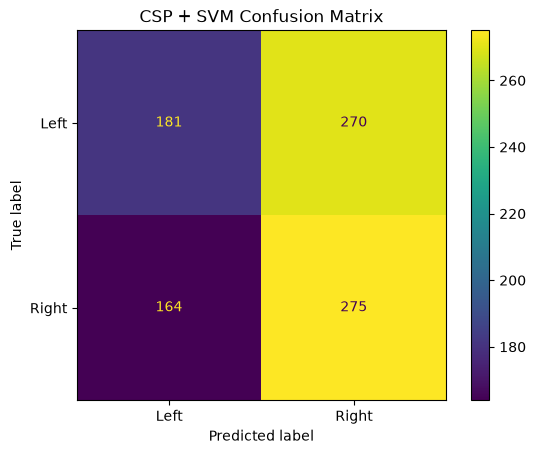

In [42]:
cm = confusion_matrix(
    y_test_num,
    y_pred_2
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Left", "Right"]
)

disp.plot()

plt.title("CSP + SVM Confusion Matrix")
plt.show()

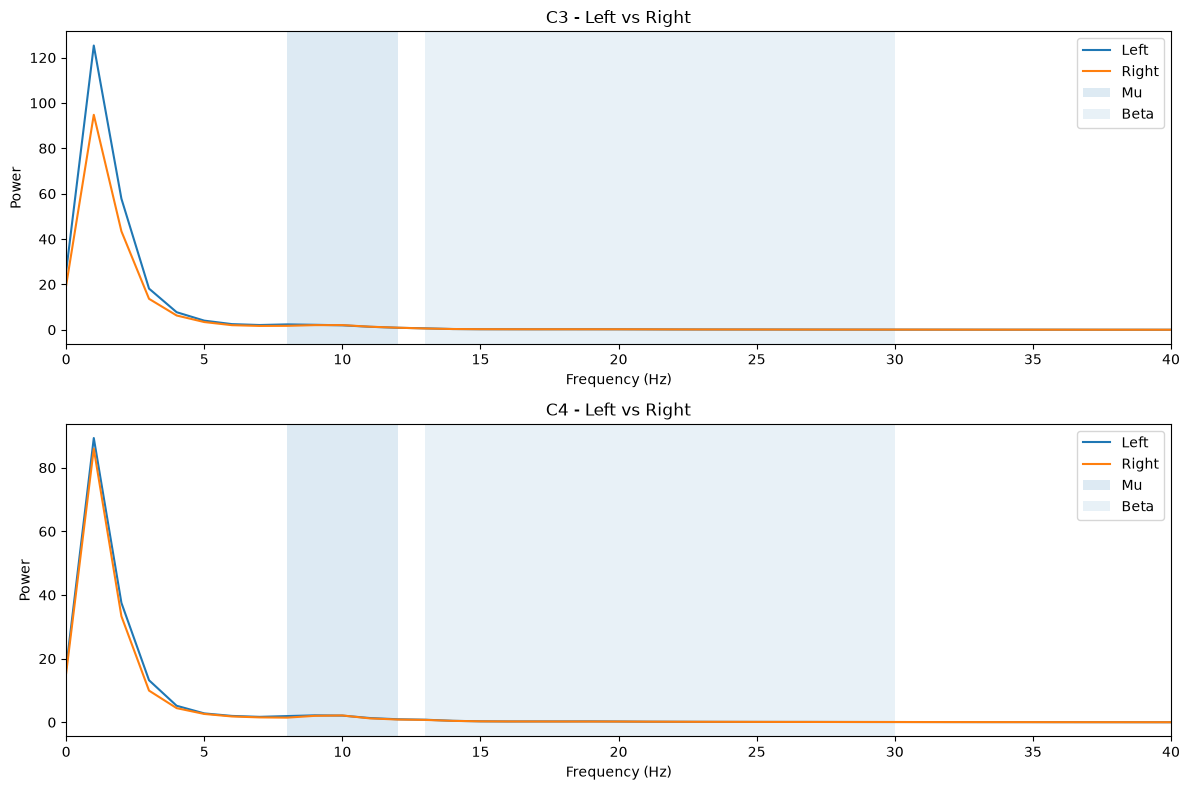

In [43]:
from scipy.signal import welch
import numpy as np
import matplotlib.pyplot as plt

def get_average_psd(X_data, y_data, channel_idx, label, fs=250):
    
    X_class = X_data[y_data == label, channel_idx, :]
    
    psds = []
    
    for epoch in X_class:
        f, pxx = welch(
            epoch,
            fs=fs,
            nperseg=250
        )
        psds.append(pxx)
    
    return f, np.mean(psds, axis=0)


# C3
f, psd_left_c3 = get_average_psd(
    X_train,
    y_train_num,
    channel_idx=1,
    label=0
)

_, psd_right_c3 = get_average_psd(
    X_train,
    y_train_num,
    channel_idx=1,
    label=1
)


# C4
_, psd_left_c4 = get_average_psd(
    X_train,
    y_train_num,
    channel_idx=3,
    label=0
)

_, psd_right_c4 = get_average_psd(
    X_train,
    y_train_num,
    channel_idx=3,
    label=1
)


fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# C3
axes[0].plot(f, psd_left_c3, label="Left")
axes[0].plot(f, psd_right_c3, label="Right")

axes[0].axvspan(8, 12, alpha=0.15, label="Mu")
axes[0].axvspan(13, 30, alpha=0.10, label="Beta")

axes[0].set_xlim(0, 40)
axes[0].set_title("C3 - Left vs Right")
axes[0].set_xlabel("Frequency (Hz)")
axes[0].set_ylabel("Power")
axes[0].legend()


# C4
axes[1].plot(f, psd_left_c4, label="Left")
axes[1].plot(f, psd_right_c4, label="Right")

axes[1].axvspan(8, 12, alpha=0.15, label="Mu")
axes[1].axvspan(13, 30, alpha=0.10, label="Beta")

axes[1].set_xlim(0, 40)
axes[1].set_title("C4 - Left vs Right")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("Power")
axes[1].legend()

plt.tight_layout()
plt.show()

In [44]:
from scipy.signal import welch
import numpy as np

def band_power(signal, fs, low, high):
    f, pxx = welch(
        signal,
        fs=fs,
        nperseg=250
    )

    mask = (f >= low) & (f <= high)

    return np.trapezoid(
        pxx[mask],
        f[mask]
    )


features = []

for epoch in X_train:

    c3 = epoch[1]
    c4 = epoch[3]

    c3_mu = band_power(c3, fs, 8, 12)
    c4_mu = band_power(c4, fs, 8, 12)

    c3_beta = band_power(c3, fs, 13, 30)
    c4_beta = band_power(c4, fs, 13, 30)

    features.append([
        c3_mu,
        c4_mu,
        c3_beta,
        c4_beta,
        c3_mu - c4_mu,
        c3_beta - c4_beta
    ])

features = np.array(features)

print("Feature shape:", features.shape)

Feature shape: (3494, 6)


In [45]:
feature_names = [
    "C3 Mu",
    "C4 Mu",
    "C3 Beta",
    "C4 Beta",
    "Mu Asymmetry",
    "Beta Asymmetry"
]

for i, name in enumerate(feature_names):

    left_mean = features[y_train_num == 0, i].mean()
    right_mean = features[y_train_num == 1, i].mean()

    print(
        f"{name:20s} | "
        f"Left: {left_mean:.4f} | "
        f"Right: {right_mean:.4f}"
    )

C3 Mu                | Left: 7.1294 | Right: 6.7928
C4 Mu                | Left: 7.0684 | Right: 6.5576
C3 Beta              | Left: 3.2155 | Right: 3.1724
C4 Beta              | Left: 3.7453 | Right: 3.5609
Mu Asymmetry         | Left: 0.0609 | Right: 0.2352
Beta Asymmetry       | Left: -0.5298 | Right: -0.3885


In [46]:
# Calculate band power using the ORIGINAL train/test split

def extract_band_power(X_data, fs=250):
    
    features = []

    for epoch in X_data:
        
        c3 = epoch[1]
        c4 = epoch[3]

        c3_mu = band_power(c3, fs, 8, 12)
        c4_mu = band_power(c4, fs, 8, 12)

        c3_beta = band_power(c3, fs, 13, 30)
        c4_beta = band_power(c4, fs, 13, 30)

        features.append([
            c3_mu,
            c4_mu,
            c3_beta,
            c4_beta
        ])

    return np.array(features)


X_train_power = extract_band_power(X_train, fs)
X_test_power = extract_band_power(X_test, fs)

print("Train power shape:", X_train_power.shape)
print("Test power shape:", X_test_power.shape)

Train power shape: (3494, 4)
Test power shape: (890, 4)


In [47]:
X_train_log = np.log1p(X_train_power)
X_test_log = np.log1p(X_test_power)

print("Train log power:")
print(pd.DataFrame(X_train_log).describe())

Train log power:
                 0            1            2            3
count  3494.000000  3494.000000  3494.000000  3494.000000
mean      1.610879     1.592287     1.238151     1.279412
std       0.833196     0.827723     0.480779     0.533991
min       0.182254     0.215892     0.431572     0.481147
25%       0.983663     0.979756     0.939152     0.924409
50%       1.424855     1.418029     1.138758     1.179158
75%       2.059069     2.053232     1.397276     1.510830
max       6.792411     6.148810     5.188052     6.101873


In [48]:
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_log)
X_test_scaled = scaler.transform(X_test_log)

In [49]:
lda_power = LinearDiscriminantAnalysis()

lda_power.fit(
    X_train_scaled,
    y_train_num
)

y_pred_power = lda_power.predict(X_test_scaled)
y_prob_power = lda_power.predict_proba(X_test_scaled)[:, 1]

print("===== Correct Band Power + LDA =====")

print(
    f"Accuracy: "
    f"{accuracy_score(y_test_num, y_pred_power):.4f}"
)

print(
    f"Balanced Accuracy: "
    f"{balanced_accuracy_score(y_test_num, y_pred_power):.4f}"
)

print(
    f"F1 Score: "
    f"{f1_score(y_test_num, y_pred_power):.4f}"
)

print(
    f"AUC: "
    f"{roc_auc_score(y_test_num, y_prob_power):.4f}"
)

===== Correct Band Power + LDA =====
Accuracy: 0.5348
Balanced Accuracy: 0.5325
F1 Score: 0.4344
AUC: 0.5385


## Summary of Experiments

Several approaches were tested to improve the classification of **Left vs Right motor imagery EEG signals**.

### 1. CSP + SVM
- Applied **Common Spatial Pattern (CSP)** to extract spatial features from the 4 EEG channels.
- Used an **RBF-kernel SVM** for classification.
- Result:
  - Accuracy: **48.72%**
  - Balanced Accuracy: **47.86%**
  - F1 Score: **13.91%**
  - AUC: **50.10%**

### 2. Band Power + LDA
- Extracted **Mu (8–12 Hz)** and **Beta (13–30 Hz)** band power features.
- Used **C3 and C4** channels.
- Trained a **Linear Discriminant Analysis (LDA)** classifier.
- Result:
  - Accuracy: **47.24%**
  - Balanced Accuracy: **46.92%**
  - F1 Score: **37.28%**
  - AUC: **47.24%**

### 3. Band Power + Random Forest
- Combined Mu and Beta band-power features.
- Used a **Random Forest Classifier** to capture possible non-linear relationships.
- Result:
  - Accuracy: **48.32%**
  - Balanced Accuracy: **48.35%**
  - F1 Score: **48.32%**
  - AUC: **46.91%**

### 4. Band-Pass Filtering (8–30 Hz) + CSP + SVM
- Applied an **8–30 Hz band-pass filter** to focus on the Mu and Beta frequency ranges.
- Extracted CSP features from the filtered signals.
- Classified the features using an **RBF SVM**.
- Result:
  - Accuracy: **48.82%**
  - Balanced Accuracy: **47.97%**
  - F1 Score: **14.78%**
  - AUC: **46.37%**

### 5. CSP with 2 Components + SVM
- Reduced the number of CSP components from 4 to **2 components**.
- Used the same RBF SVM classifier.
- This was tested to determine whether fewer spatial features could improve generalization.

### 6. Relative Band Power + LDA / Random Forest
- Cropped the EEG signals to a selected time window.
- Extracted relative Mu and Beta band power.
- Tested both **LDA** and **Random Forest** classifiers.

### 7. Data Cleaning
- Removed epochs with unusually high amplitudes using a **100 µV threshold**.
- The cleaned data was then tested with CSP + SVM and band-power-based approaches.

### 8. Time-Domain Features + Random Forest
Several statistical features were extracted from each channel, including:
- Mean
- Standard deviation
- Variance
- RMS
- Skewness
- Kurtosis

Then, **SelectKBest** was used for feature selection, followed by a Random Forest classifier.

### 9. Z-Score Normalization
- Applied per-epoch Z-score normalization to reduce differences in signal amplitude between epochs.
- Tested the normalized time-domain features using a simpler Random Forest model.

### 10. Log Transformation + Scaling
- Applied `log1p` transformation to band-power features.
- Used **StandardScaler / RobustScaler** to normalize the feature distributions.
- Tested the transformed features with LDA.

### Overall Observation

The tested models achieved accuracies close to **48–49%**, which is around chance level for this binary classification problem.

The best result among the initial experiments was obtained using:

**8–30 Hz CSP + SVM → Accuracy ≈ 48.82%**

The results suggest that the current spatial and frequency-domain features are not providing sufficient separation between the **Left** and **Right** classes. Further improvement may require better preprocessing, subject/session normalization, more informative EEG channels, improved epoch selection, or more advanced feature extraction and classification methods.